In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# import nessary libraries
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
#imagae preprocessing
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
# Import Keras layers, models, and optimizers from TensorFlow
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
# import nessary libraries
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import gradio as gr
import keras
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

2025-09-08 15:25:17.912136: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757345118.168907      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757345118.237628      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
Base_bath = '/kaggle/input/plantvillage-dataset/color'
Train_path = None 
Test_path  = None
image_size = (128, 128)
batch_size = 4
num_classes = None 

In [3]:
def split_dataset(input_dir, output_dir, test_size=0.15, val_size=0.15, random_state=42):
    """
    Splits datasetrain/vt into al/test sets while preserving directory structure

    Args:
        input_dir: Path to raw dataset (with class subfolders)
        output_dir: Path to save split datasets
        test_size: Proportion for test set (0-1)
        val_size: Proportion for validation set (0-1)
        random_state: Random seed for reproducibility
    """
    # Create output directories
    os.makedirs(os.path.join(output_dir, 'train'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'val'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'test'), exist_ok=True)

    # Get all class folders
    classes = [d for d in os.listdir(input_dir)
               if os.path.isdir(os.path.join(input_dir, d))]

    for class_name in tqdm(classes, desc="Processing classes"):
        # Create class subdirectories in each split
        os.makedirs(os.path.join(output_dir, 'train', class_name), exist_ok=True)
        os.makedirs(os.path.join(output_dir, 'val', class_name), exist_ok=True)
        os.makedirs(os.path.join(output_dir, 'test', class_name), exist_ok=True)

        # Get all image files for current class
        class_dir = os.path.join(input_dir, class_name)
        images = [f for f in os.listdir(class_dir)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Split into train+temp, then temp into val+test
        train, temp = train_test_split(
            images,
            test_size=(test_size + val_size),
            random_state=random_state
        )
        val, test = train_test_split(
            temp,
            test_size=test_size/(test_size+val_size),
            random_state=random_state
        )

        for phase, files in [('train', train), ('val', val), ('test', test)]:
            for file in files:
                src = os.path.join(class_dir, file)
                dst = os.path.join(output_dir, phase, class_name, file)

                if os.path.exists(src):
                    os.makedirs(os.path.dirname(dst), exist_ok=True)
                    shutil.copy2(src, dst)
                else:
                    print(f"Warning: File not found and skipped: {src}")

        # Print stats per class
        print(f"\n{class_name}:")
        print(f"  Train: {len(train)} images")
        print(f"  Val: {len(val)} images")
        print(f"  Test: {len(test)} images")

    print("\nDataset splitting completed successfully!")
    print(f"Total classes processed: {len(classes)}")

# Example Usage

    # Set your paths here
RAW_DATA_DIR = Base_bath
SPLIT_DATA_DIR = "/kaggle/working/"  # Where to save the splits

    # Split ratios (test_size + val_size should be < 1)
split_dataset(
        input_dir=RAW_DATA_DIR,
        output_dir=SPLIT_DATA_DIR,
        test_size=0.15,  # 15% test
        val_size=0.15,   # 15% validation
        random_state=42  # For reproducibility
    )

Processing classes:   3%|▎         | 1/38 [00:08<04:56,  8.02s/it]


Tomato___Late_blight:
  Train: 1336 images
  Val: 286 images
  Test: 287 images


Processing classes:   5%|▌         | 2/38 [00:14<04:15,  7.09s/it]


Tomato___healthy:
  Train: 1113 images
  Val: 239 images
  Test: 239 images


Processing classes:   8%|▊         | 3/38 [00:15<02:36,  4.48s/it]

...


Tomato___Spider_mites Two-spotted_spider_mite:
  Train: 1173 images
  Val: 251 images
  Test: 252 images


Processing classes:  97%|█████████▋| 37/38 [06:55<00:09,  9.36s/it]


Pepper,_bell___Bacterial_spot:
  Train: 697 images
  Val: 150 images
  Test: 150 images


Processing classes: 100%|██████████| 38/38 [07:04<00:00, 11.17s/it]


Corn_(maize)___healthy:
  Train: 813 images
  Val: 174 images
  Test: 175 images

Dataset splitting completed successfully!
Total classes processed: 38


In [5]:
def show_random_images_cv2(base_dir="dataset", num_images=12, image_size=(250, 128)):
    image_paths = []
    for brand in os.listdir(base_dir):
        brand_folder = os.path.join(base_dir, brand)
        if os.path.isdir(brand_folder):
            for img_file in os.listdir(brand_folder):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                    image_paths.append(os.path.join(brand_folder, img_file))

    selected = random.sample(image_paths, min(num_images, len(image_paths)))

    cols = 4
    rows = (len(selected) + cols - 1) // cols
    plt.figure(figsize=(cols * 3, rows * 3))

    for i, img_path in enumerate(selected):
        img = cv2.imread(img_path)
        if img is None:
            continue  # skip unreadable files
        img = cv2.resize(img, image_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert from BGR to RGB

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(os.path.dirname(img_path)))

    plt.tight_layout()
    plt.show()

In [7]:
Train_path="/kaggle/working/train"
Test_path  = "/kaggle/working/test"
Val_path="/kaggle/working/val"
batch_size = 4
num_classes = len(labels_dict) 

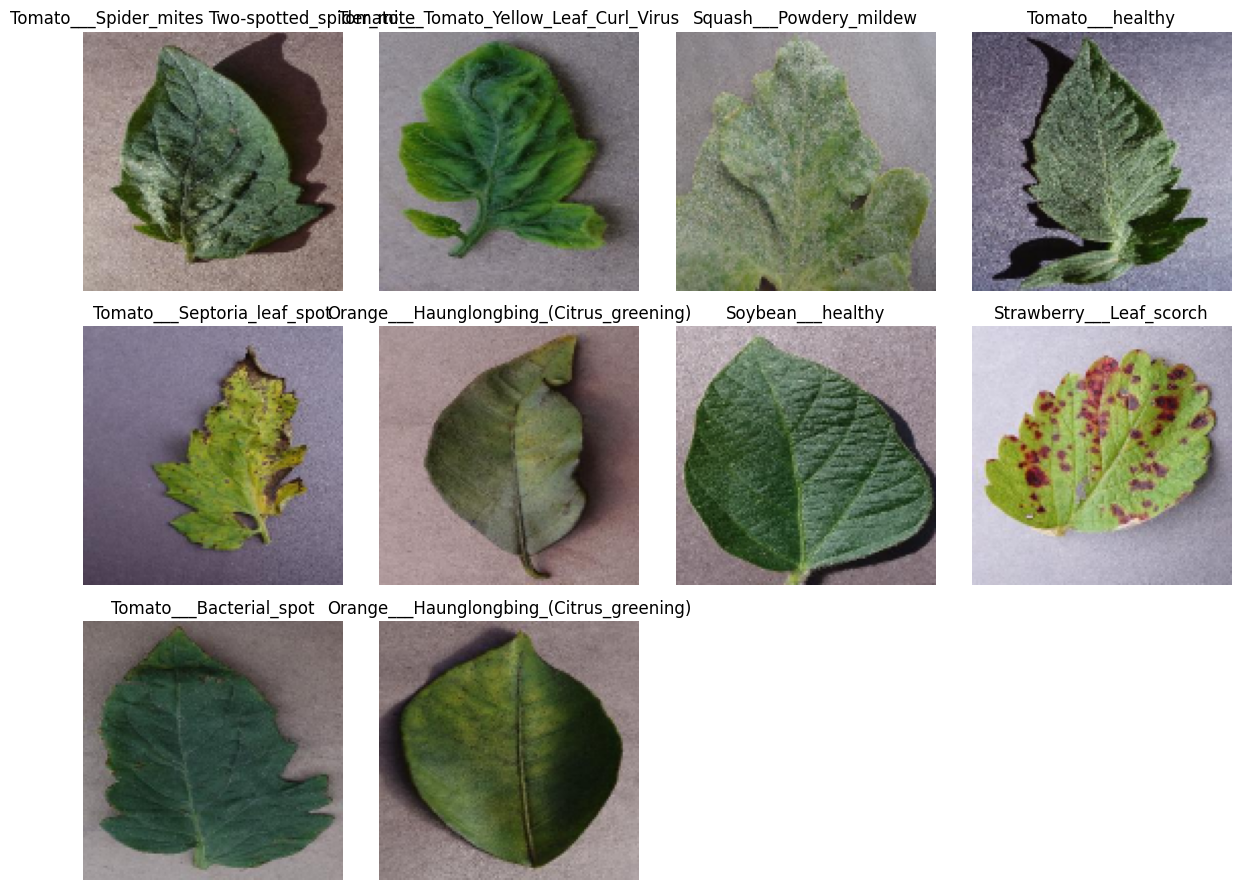

In [13]:
show_random_images_cv2(base_dir=Train_path, num_images=10, image_size=(128,128))

In [16]:
# prompt: make the labels dictionary

import os

def make_labels_dict(dataset_path):
    labels = {}
    i = 0
    for brand in os.listdir(dataset_path):
        brand_dir = os.path.join(dataset_path, brand)
        if os.path.isdir(brand_dir):
            labels[brand] = i
            i += 1
    return labels

# Example usage (assuming the dataset path is correct):
labels_dict = make_labels_dict(Train_path)
labels_dict


{'Cherry_(including_sour)___healthy': 0,
 'Grape___healthy': 1,
 'Tomato___Early_blight': 2,
 'Peach___Bacterial_spot': 3,
 'Squash___Powdery_mildew': 4,
 'Tomato___Spider_mites Two-spotted_spider_mite': 5,
 'Grape___Esca_(Black_Measles)': 6,
 'Tomato___Bacterial_spot': 7,
 'Corn_(maize)___Northern_Leaf_Blight': 8,
 'Tomato___Target_Spot': 9,
 'Potato___healthy': 10,
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 11,
 'Orange___Haunglongbing_(Citrus_greening)': 12,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 13,
 'Cherry_(including_sour)___Powdery_mildew': 14,
 'Blueberry___healthy': 15,
 'Pepper,_bell___healthy': 16,
 'Pepper,_bell___Bacterial_spot': 17,
 'Potato___Early_blight': 18,
 'Apple___Cedar_apple_rust': 19,
 'Tomato___Septoria_leaf_spot': 20,
 'Apple___healthy': 21,
 'Soybean___healthy': 22,
 'Grape___Black_rot': 23,
 'Tomato___Tomato_mosaic_virus': 24,
 'Raspberry___healthy': 25,
 'Strawberry___healthy': 26,
 'Tomato___healthy': 27,
 'Grape___Leaf_blight_(Isariopsis_L

In [19]:
import os
import cv2
import numpy as np

def load_data_binary(dataset_paths, labels_dict, image_size=(128,128), augment=False):
    # Make labels_dict keys lowercase for matching
    labels_dict = {k.lower(): v for k, v in labels_dict.items()}

    X, y = [], []
    for dataset_path in dataset_paths:
        print("Looking in:", dataset_path)

        for folder in os.listdir(dataset_path):
            folder_lower = folder.lower()
            if folder_lower not in labels_dict:
                print("Skipping folder:", folder)
                continue

            label = labels_dict[folder_lower]
            folder_path = os.path.join(dataset_path, folder)
            print("Processing:", folder_path)

            for img_file in os.listdir(folder_path):
                if not img_file.lower().endswith((".png",".jpg",".jpeg")):
                    continue
                img_path = os.path.join(folder_path, img_file)
                img = cv2.imread(img_path)
                if img is None:
                    print("Could not read:", img_path)
                    continue

                img = cv2.resize(img, image_size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                X.append(img)
                y.append(label)

                if augment:
                    X.append(cv2.flip(img,1)); y.append(label)
                    for angle in [15, -15]:
                        M = cv2.getRotationMatrix2D((image_size[0]//2, image_size[1]//2), angle, 1)
                        X.append(cv2.warpAffine(img, M, image_size))
                        y.append(label)

    print(f"Loaded {len(X)} images")
    X = np.array(X, dtype="float32") / 255.0
    y = np.array(y, dtype="float32")
    
    return X, y


In [20]:
X_train, y_train = load_data_binary([Train_path], labels_dict, image_size)
X_test, y_test   = load_data_binary([Test_path], labels_dict, image_size)

Looking in: /kaggle/working/train
Processing: /kaggle/working/train/Cherry_(including_sour)___healthy
Processing: /kaggle/working/train/Grape___healthy
Processing: /kaggle/working/train/Tomato___Early_blight
Processing: /kaggle/working/train/Peach___Bacterial_spot
Processing: /kaggle/working/train/Squash___Powdery_mildew
Processing: /kaggle/working/train/Tomato___Spider_mites Two-spotted_spider_mite
Processing: /kaggle/working/train/Grape___Esca_(Black_Measles)
Processing: /kaggle/working/train/Tomato___Bacterial_spot
Processing: /kaggle/working/train/Corn_(maize)___Northern_Leaf_Blight
Processing: /kaggle/working/train/Tomato___Target_Spot
Processing: /kaggle/working/train/Potato___healthy
Processing: /kaggle/working/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus
Processing: /kaggle/working/train/Orange___Haunglongbing_(Citrus_greening)
Processing: /kaggle/working/train/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Processing: /kaggle/working/train/Cherry_(including_sour)___Powdery

In [41]:
X_val, y_val   = load_data_binary([Val_path], labels_dict, image_size)

Looking in: /kaggle/working/val
Processing: /kaggle/working/val/Cherry_(including_sour)___healthy
Processing: /kaggle/working/val/Grape___healthy
Processing: /kaggle/working/val/Tomato___Early_blight
Processing: /kaggle/working/val/Peach___Bacterial_spot
Processing: /kaggle/working/val/Squash___Powdery_mildew
Processing: /kaggle/working/val/Tomato___Spider_mites Two-spotted_spider_mite
Processing: /kaggle/working/val/Grape___Esca_(Black_Measles)
Processing: /kaggle/working/val/Tomato___Bacterial_spot
Processing: /kaggle/working/val/Corn_(maize)___Northern_Leaf_Blight
Processing: /kaggle/working/val/Tomato___Target_Spot
Processing: /kaggle/working/val/Potato___healthy
Processing: /kaggle/working/val/Tomato___Tomato_Yellow_Leaf_Curl_Virus
Processing: /kaggle/working/val/Orange___Haunglongbing_(Citrus_greening)
Processing: /kaggle/working/val/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Processing: /kaggle/working/val/Cherry_(including_sour)___Powdery_mildew
Processing: /kaggle/work

In [21]:
print("Training data shape:", X_train.shape, y_train.shape)
print("Test data shape:", X_test.shape, y_test.shape)

Training data shape: (37998, 128, 128, 3) (37998,)
Test data shape: (8162, 128, 128, 3) (8162,)


In [22]:
from sklearn.preprocessing import OneHotEncoder

# Reshape to 2D
y_train = y_train.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

# Initialize encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit & transform
y_train = encoder.fit_transform(y_train)
y_test  = encoder.transform(y_test)

print("y_train one-hot shape:", y_train.shape)
print("y_test one-hot shape:", y_test.shape)


y_train one-hot shape: (37998, 38)
y_test one-hot shape: (8162, 38)


In [42]:
from sklearn.preprocessing import OneHotEncoder

# Reshape to 2D
y_val = y_val.reshape(-1, 1)

# Initialize encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit & transform
y_val = encoder.fit_transform(y_val)

print("y_val one-hot shape:", y_val.shape)


y_val one-hot shape: (8145, 38)


In [24]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False  # Freeze base


In [25]:

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)



In [26]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        38,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,278,950 (58.28 MB)

 Trainable params: 564,262 (2.15 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [28]:
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])


In [29]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]


In [30]:


history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/50


I0000 00:00:1757346525.075485     101 service.cc:148] XLA service 0x7c342800f0b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757346525.076342     101 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1757346525.589587     101 cuda_dnn.cc:529] Loaded cuDNN version 90300


   5/1188 ━━━━━━━━━━━━━━━━━━━━ 34s 29ms/step - accuracy: 0.0366 - loss: 3.5687

I0000 00:00:1757346529.986581     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 55s 40ms/step - accuracy: 0.3964 - loss: 2.4142 - val_accuracy: 0.7118 - val_loss: 1.1080 - learning_rate: 1.0000e-04
Epoch 2/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.7522 - loss: 0.9724 - val_accuracy: 0.8003 - val_loss: 0.7431 - learning_rate: 1.0000e-04
Epoch 3/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.8130 - loss: 0.6904 - val_accuracy: 0.8312 - val_loss: 0.6003 - learning_rate: 1.0000e-04
Epoch 4/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.8407 - loss: 0.5593 - val_accuracy: 0.8482 - val_loss: 0.5244 - learning_rate: 1.0000e-04
Epoch 5/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.8606 - loss: 0.4861 - val_accuracy: 0.8580 - val_loss: 0.4679 - learning_rate: 1.0000e-04
Epoch 6/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.8707 - loss: 0.4383 - val_accuracy: 0.8647 - val_loss: 0.4432 - learning_rate: 1.0000e-04
Epoch 7/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/

In [31]:

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9227 - loss: 0.2405
Test Accuracy: 0.9243, Test Loss: 0.2301


In [44]:

Val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"val Accuracy: {val_acc:.4f}, val Loss: {Val_loss:.4f}")

255/255 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9175 - loss: 0.2321
Test Accuracy: 0.9215, Test Loss: 0.2308


In [32]:
# حفظ الموديل بالكامل
model.save("PlantVillage.keras")
print("Modelsaved successfully!")

Modelsaved successfully!


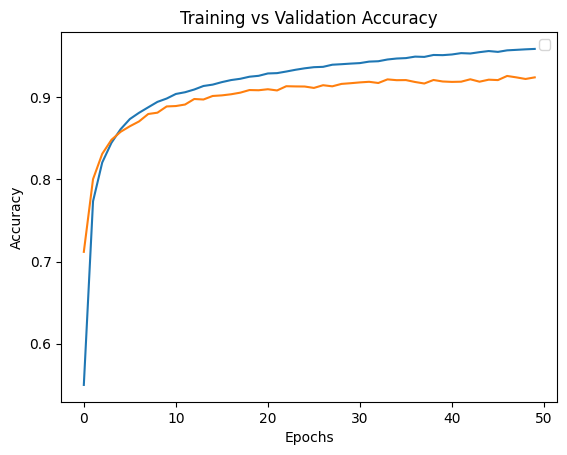

In [33]:
# --- Plot Accuracy ---
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'] )
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()


256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step
Classification Report:
                                                    precision    recall  f1-score   support

                 Cherry_(including_sour)___healthy       0.96      0.98      0.97       129
                                   Grape___healthy       1.00      0.97      0.98        64
                             Tomato___Early_blight       0.59      0.61      0.60       150
                            Peach___Bacterial_spot       0.96      0.97      0.97       345
                           Squash___Powdery_mildew       0.99      0.99      0.99       276
     Tomato___Spider_mites Two-spotted_spider_mite       0.84      0.91      0.88       252
                      Grape___Esca_(Black_Measles)       0.85      0.92      0.88       208
                           Tomato___Bacterial_spot       0.86      0.93      0.89       320
               Corn_(maize)___Northern_Leaf_Blight       0.82      0.93      0.87       148
              

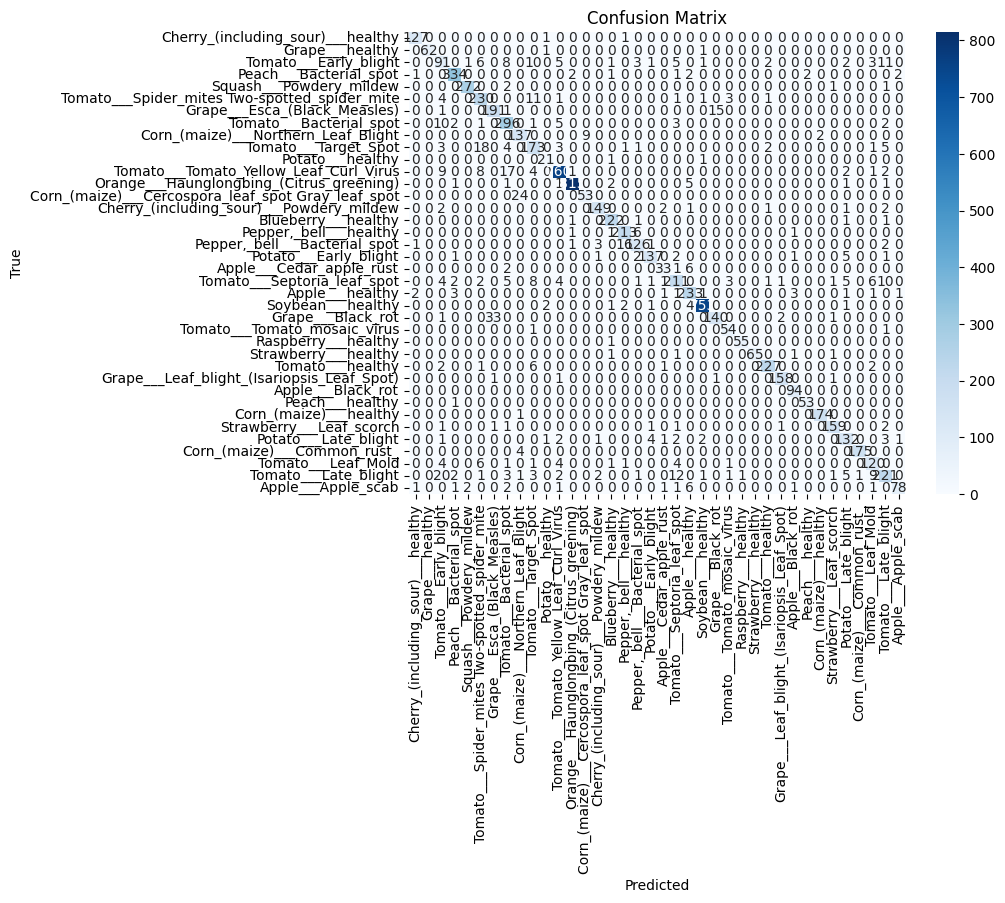

In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# If y_test is one-hot encoded, convert to class indices
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test.astype(int)

# Predictions: get class indices from softmax probabilities
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names in order of labels
target_names = labels_dict


# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [47]:
# ===============================
# Plant Disease Classification App
# ===============================

import gradio as gr
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image

# 1️⃣ Load your trained Plant Disease model

# 2️⃣ Class names in correct order (حسب dataset)

# 3️⃣ Prediction function
def predict_plant_disease(image):
    # Convert PIL image to numpy
    img = np.array(image)
    img = cv2.resize(img, (224, 224))     # Resize same as training
    img = img / 255.0                     # Normalize
    img = np.expand_dims(img, axis=0)     # Add batch dimension

    # Prediction
    pred_probs = model.predict(img)[0]    # shape: (num_classes,)

    # Return dictionary for Gradio using labels_dict
    return {labels_dict[i]: float(pred_probs[i]) for i in range(len(pred_probs))}




In [48]:
# 4️⃣ Gradio Interface
interface = gr.Interface(
    fn=predict_plant_disease,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),  # Top 3 predictions
    title="Plant Disease Classifier",
    description="Upload a leaf image and the model will classify it into the correct plant disease.",
    examples=None  # يمكن إضافة بعض الأمثلة هنا
)

# 5️⃣ Launch the app
interface.launch(share=True)


* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://3b41236fd112d3190b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
